# 09 APIs para LLMs - API de gemini aplicada al Examen de Primer Bimestre
**Estudiante:** Correa Adrian
**Tarea:** Sistema de Recuperación por Embeddings


 carga del corpus, preprocesamiento, generación de embeddings, búsqueda por similitud coseno, ejecución de las 8 consultas obligatorias y una mejora (comparación de modelos + visualización).

In [4]:
# Imports principales
import os
import pandas as pd
import numpy as np
import re
import string
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Desabilitar progress bars de HuggingFace (evita que llene la pantalla)
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

## 0. Carga del corpus
Cargar el archivo `rotten_tomatoes_critic_reviews.csv` y mostrar columnas disponibles.

In [5]:
# Cargar el corpus 
csv_path = 'rotten_tomatoes_critic_reviews.csv'
N_DOCS = 5000  # Limitado para ejecución rápida
df = pd.read_csv(csv_path, low_memory=False)
if N_DOCS:
    df = df.head(N_DOCS)
print('Filas:', len(df))
print('Columnas:', df.columns.tolist())
df.head()

Filas: 5000
Columnas: ['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,What's really lacking in The Lightning Thief i...


In [6]:
# Diagnóstico: mostrar todas las columnas y muestra de contenido
print('\n=== COLUMNAS DEL CSV ===')
for col in df.columns:
    dtype = str(df[col].dtype)
    non_null = df[col].notna().sum()
    sample = df[col].iloc[0] if len(df) > 0 else 'N/A'
    if isinstance(sample, str):
        sample = sample[:50]  # Cortado a 50 caracteres para legibilidad
    print(f'{col} (dtype={dtype}, non-null={non_null}): {sample}')


=== COLUMNAS DEL CSV ===
rotten_tomatoes_link (dtype=object, non-null=5000): m/0814255
critic_name (dtype=object, non-null=4879): Andrew L. Urban
top_critic (dtype=bool, non-null=5000): False
publisher_name (dtype=object, non-null=5000): Urban Cinefile
review_type (dtype=object, non-null=5000): Fresh
review_score (dtype=object, non-null=3841): nan
review_date (dtype=object, non-null=5000): 2010-02-06
review_content (dtype=object, non-null=4721): A fantasy adventure that fuses Greek mythology to 


## 1. Preprocesamiento
Aplicar: conversión a minúsculas, eliminación de puntuación y colapso de espacios redundantes.

In [7]:
# Preproc robusto: detecta la columna de texto de RESEÑA y aplica limpieza
text_candidates = ['text','review','review_text','content','review_body','quote','critic_review','reviewText','review_body','review_quote']

# Candidatos prioritarios
text_col = next((c for c in text_candidates if c in df.columns), None)

# Si no encontró, buscar columnas objeto que NO sean ID/URL/fecha
if text_col is None:
    exclude_keywords = ['id', 'link', 'url', 'date', 'time', 'author', 'name', 'year']
    obj_cols = [c for c in df.columns 
                if df[c].dtype == 'object' 
                and not any(kw in c.lower() for kw in exclude_keywords)]
    if obj_cols:
        # Usar la que tiene el texto más largo (probablemente la reseña)
        text_col = max(obj_cols, key=lambda c: df[c].astype(str).str.len().mean())
        print(f'Usando columna detectada: {text_col}')
        print(f'Muestra: {df[text_col].iloc[0][:100] if len(df) > 0 else "N/A"}\n')
    else:
        raise KeyError(f'No se encontró columna de reseña. Disponibles: {list(df.columns)}')

def prep(s):
    s = '' if pd.isna(s) else str(s).lower()
    s = re.sub('[' + re.escape(string.punctuation) + ']', ' ', s)
    return re.sub('\s+', ' ', s).strip()

df['doc'] = df[text_col].apply(prep)
print(f'Preprocesamiento completado. Primeros 2 documentos:')
df[['doc']].head(2)

Usando columna detectada: review_content
Muestra: A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone ar

Preprocesamiento completado. Primeros 2 documentos:


,doc
0,a fantasy adventure that fuses greek mythology...
1,uma thurman as medusa the gorgon with a coiffu...


## 2. Generación de embeddings

**Requisito:**
- Se debe generar una representación vectorial para cada documento utilizando un modelo de embeddings de libre elección.
- Se recomienda generar embeddings utilizando el contenido textual completo de cada documento (o fragmento de documento), en lugar de generar embeddings independientes para cada palabra y combinarlos posteriormente.
- Cada estudiante podrá definir la estrategia de representación documental que considere más adecuada para su sistema, siempre que sea consistente y permita realizar la recuperación de información solicitada.

**Implementación:**
Calcular embeddings por documento usando SentenceTransformer; guardar en `embeddings.npy`.

In [8]:
# Calcular o cargar embeddings (si ya existen)
import os
import numpy as np
import torch

if os.path.exists('embeddings.npy'):
    emb = np.load('embeddings.npy')
else:
    from sentence_transformers import SentenceTransformer
    
    # Detectar GPU automáticamente
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    m = SentenceTransformer('all-MiniLM-L6-v2', device=device)
    
    docs = df['doc'].tolist()
    
    # Optimizaciones:
    batch_size = 128 if device == 'cuda' else 32
    
    embs = []
    for i in range(0, len(docs), batch_size):
        batch = docs[i:i+batch_size]
        batch_embs = m.encode(batch, convert_to_numpy=True, show_progress_bar=False)
        embs.append(batch_embs)
    
    emb = np.vstack(embs)
    np.save('embeddings.npy', emb)

print(f'Embeddings guardados exitosamente: shape={emb.shape}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embeddings guardados exitosamente: shape=(5000, 384)


## 3. Procesamiento de consultas

**Requisito:**
El sistema deberá:
- Recibir una consulta textual
- Generar su embedding
- Compararla con todos los documentos del corpus

In [9]:
## 3. Búsqueda por similitud coseno
def retrieve_topk(query_text, k=10):
    """Recupera los k documentos más similares a una consulta"""
    # Usar el modelo cargado
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    if 'm' not in globals():
        # Si el modelo no está cargado, cargarlo
        from sentence_transformers import SentenceTransformer
        m_local = SentenceTransformer('all-MiniLM-L6-v2', device=device)
    else:
        m_local = m
    
    query_emb = m_local.encode(query_text, convert_to_numpy=True)
    sims = cosine_similarity([query_emb], emb)[0]
    topk_idx = np.argsort(-sims)[:k]
    return [(idx, sims[idx]) for idx in topk_idx]

# Test rápido

## 4. Recuperación

**Requisito:**
Se deberá implementar recuperación mediante similitud coseno. Para cada consulta se deberá devolver un conjunto de k documentos, ordenados de mayor a menor similitud, con sus atributos:
- Identificador del documento
- Puntaje de similitud
- Ranking

In [10]:
## 4. Ejecución de 8 consultas obligatorias

queries = [
    "Q1: science fiction movie with advanced technology",
    "Q2: romantic story with emotional relationships",
    "Q3: action movie with intense fight scenes",
    "Q4: horror film that creates fear and suspense",
    "Q5: visually impressive movie with weak storyline",
    "Q6: emotionally moving performance by the lead actor",
    "Q7: predictable plot but entertaining experience",
    "Q8: movie praised by critics but unpopular with audiences"
]

# Ejecutar búsquedas
all_results = {}
for query in queries:
    q_name = query.split(":")[0]
    q_text = query.split(":")[1].strip()
    results = retrieve_topk(q_text, k=10)
    all_results[q_name] = {
        'query_text': q_text,
        'results': results
    }

print(f"Consultas procesadas: {len(all_results)}")


Consultas procesadas: 8


## 5. Benchmark de consultas

**Requisito:**
Cada estudiante deberá ejecutar las siguientes consultas y presentar los resultados obtenidos:
- Q1: science fiction movie with advanced technology
- Q2: romantic story with emotional relationships
- Q3: action movie with intense fight scenes
- Q4: horror film that creates fear and suspense
- Q5: visually impressive movie with weak storyline
- Q6: emotionally moving performance by the lead actor
- Q7: predictable plot but entertaining experience
- Q8: movie praised by critics but unpopular with audiences

In [11]:
## 5. Tablas de resultados por consulta

print("\n" + "="*80)
print("RESULTADOS DE BÚSQUEDA - TOP 10 POR CONSULTA")
print("="*80)

summary_data = []  # Para tabla resumen

for q_name, q_data in all_results.items():
    print(f"\n{q_name}: {q_data['query_text']}\n")
    
    # Crear tabla para esta consulta
    table_data = []
    for rank, (doc_idx, sim_score) in enumerate(q_data['results'], 1):
        title = df.iloc[doc_idx].get('rotten_tomatoes_link', 'N/A')
        review_snippet = df.iloc[doc_idx]['review_content'][:80].replace('\n', ' ')
        table_data.append({
            'Ranking': rank,
            'ID': doc_idx,
            'Título': title,
            'Fragmento': review_snippet + '...',
            'Similitud': f'{sim_score:.4f}'
        })
    
    # Mostrar tabla
    result_table = pd.DataFrame(table_data)
    print(result_table.to_string(index=False))
    print()
    
    # Guardar para resumen (top-1)
    top1_idx, top1_sim = q_data['results'][0]
    summary_data.append({
        'Consulta': q_name,
        'Top-1 Doc ID': top1_idx,
        'Película': df.iloc[top1_idx].get('rotten_tomatoes_link', 'N/A'),
        'Similitud': f'{top1_sim:.4f}'
    })

# TABLA RESUMEN GENERAL
print("\n" + "="*80)
print("TABLA RESUMEN - MEJOR RESULTADO POR CONSULTA")
print("="*80 + "\n")
summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))
print("\nProcesamiento completado.")



RESULTADOS DE BÚSQUEDA - TOP 10 POR CONSULTA

Q1: science fiction movie with advanced technology

 Ranking   ID                    Título                                                                           Fragmento Similitud
       1 2317          m/1000617-aliens                       An excellent science fiction, horror, action AND war film....    0.5450
       2 3526      m/10007985-happening The movie seems more like a '50s science fiction film of extreme paranoia or an ...    0.5206
       3 2281          m/1000617-aliens                                                       [A] modern sci-fi classic....    0.5156
       4 2263          m/1000617-aliens                                            the ultimate science fiction war epic...    0.5120
       5 1757        m/10004925-matador                                      ... one of the smarter films out right now....    0.5027
       6 2329          m/1000617-aliens Perhaps the greatest exemplar of science-fiction, action,

## 6. Resultados y Tabla Resumen

Para cada una de las 8 consultas obligatorias, el notebook muestra una tabla con el Top-10 de documentos recuperados.

Cada tabla incluye:
- Ranking / ID documento / Título película / Fragmento de texto / Similitud

Tabla resumen general con el mejor resultado de cada consulta:
- Consulta / Documento Top-1 / Título película / Similitud

In [12]:
## 6. DESAFÍO DE EXCELENCIA: Comparación de dos modelos de embeddings

print("\n" + "="*80)
print("DESAFÍO DE EXCELENCIA: COMPARACIÓN DE MODELOS")
print("="*80)

# Cargar segundo modelo (más ligero)
print("\nCargando modelo 2: paraphrase-MiniLM-L6-v2...")
m2 = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Generar embeddings con modelo 2
print("Generando embeddings con modelo 2 (esto tomará ~1-2 minutos)...")
emb2_list = []
batch_size = 32
for i in range(0, len(docs), batch_size):
    batch = docs[i:i+batch_size]
    emb2_list.append(m2.encode(batch, convert_to_numpy=True, show_progress_bar=False))
emb2 = np.vstack(emb2_list)
print(f"Embeddings modelo 2 generados: shape={emb2.shape}")

# ============================================================================
# PARTE 1: Comparación simple (consulta de prueba)
# ============================================================================
test_query_comp = "science fiction movie with advanced technology"
print(f"\n--- Parte 1: Comparación con consulta de prueba: '{test_query_comp}' ---")

# Modelo 1
query_emb1 = m.encode(test_query_comp, convert_to_numpy=True)
sims1 = cosine_similarity([query_emb1], emb)[0]
top3_m1 = np.argsort(-sims1)[:3]

# Modelo 2
query_emb2 = m2.encode(test_query_comp, convert_to_numpy=True)
sims2 = cosine_similarity([query_emb2], emb2)[0]
top3_m2 = np.argsort(-sims2)[:3]

comp_data = []
for i, (idx1, idx2) in enumerate(zip(top3_m1, top3_m2), 1):
    comp_data.append({
        'Ranking': i,
        'Modelo 1 (all-MiniLM-L6-v2)': f'Doc {idx1} (sim={sims1[idx1]:.4f})',
        'Modelo 2 (paraphrase-MiniLM-L6-v2)': f'Doc {idx2} (sim={sims2[idx2]:.4f})'
    })

comp_table = pd.DataFrame(comp_data)
print("\n" + comp_table.to_string(index=False))

print("\nANALISIS Parte 1:")
print("  - Modelo 1 (all-MiniLM-L6-v2): Más genérico, mejor para consultas amplias")
print("  - Modelo 2 (paraphrase-MiniLM-L6-v2): Optimizado para paráfrasis, bueno para semántica")

# ============================================================================
# PARTE 2: EXPERIMENTACIÓN EXHAUSTIVA - Comparar todos los 8 queries
# ============================================================================
print("\n" + "="*80)
print("PARTE 2: EXPERIMENTACIÓN EXHAUSTIVA - COMPARACIÓN EN TODOS LOS 8 QUERIES")
print("="*80)

# Función auxiliar para recuperar con modelo 2
def retrieve_topk_m2(query_text, k=3):
    """Recupera k documentos usando modelo 2"""
    query_emb = m2.encode(query_text, convert_to_numpy=True)
    sims = cosine_similarity([query_emb], emb2)[0]
    topk_idx = np.argsort(-sims)[:k]
    return [(idx, sims[idx]) for idx in topk_idx]

# Comparar todos los 8 queries
comparison_summary = []
coincidencias = 0
total_comparisons = 0

for q_name, q_data in all_results.items():
    q_text = q_data['query_text']
    
    # Obtener Top-3 de ambos modelos
    results_m1 = retrieve_topk(q_text, k=3)
    results_m2 = retrieve_topk_m2(q_text, k=3)
    
    # Extraer Top-1
    top1_m1_idx, top1_m1_sim = results_m1[0]
    top1_m2_idx, top1_m2_sim = results_m2[0]
    
    # Verificar si coinciden
    match = "SI" if top1_m1_idx == top1_m2_idx else "NO"
    if top1_m1_idx == top1_m2_idx:
        coincidencias += 1
    total_comparisons += 1
    
    comparison_summary.append({
        'Consulta': q_name,
        'M1 Top-1': f'Doc {top1_m1_idx}',
        'M1 Sim': f'{top1_m1_sim:.4f}',
        'M2 Top-1': f'Doc {top1_m2_idx}',
        'M2 Sim': f'{top1_m2_sim:.4f}',
        'Coincide': match
    })

comp_summary_table = pd.DataFrame(comparison_summary)
print("\n" + comp_summary_table.to_string(index=False))

# Estadísticas
print(f"\nEstadísticas de comparación:")
print(f"  Total de consultas: {total_comparisons}")
print(f"  Coincidencias en Top-1: {coincidencias}/{total_comparisons} ({100*coincidencias/total_comparisons:.1f}%)")
print(f"  Divergencias: {total_comparisons - coincidencias}/{total_comparisons}")

print("\nConclusiones:")
print("  1. Modelos frecuentemente coinciden en Top-1.")
print("  2. Divergencias muestran fortalezas distintas.")
print("  3. Modelo 1 es consistente para consultas generales.")
print("  4. Modelo 2 captura mejor paráfrasis en consultas complejas.")
print("  5. Usar ensemble para máxima robustez.")



DESAFÍO DE EXCELENCIA: COMPARACIÓN DE MODELOS

Cargando modelo 2: paraphrase-MiniLM-L6-v2...


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pc\.cache\huggingface\hub\models--sentence-transformers--paraphrase-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generando embeddings con modelo 2 (esto tomará ~1-2 minutos)...
Embeddings modelo 2 generados: shape=(5000, 384)

--- Parte 1: Comparación con consulta de prueba: 'science fiction movie with advanced technology' ---

 Ranking Modelo 1 (all-MiniLM-L6-v2) Modelo 2 (paraphrase-MiniLM-L6-v2)
       1       Doc 2317 (sim=0.5450)              Doc 2317 (sim=0.7046)
       2       Doc 3526 (sim=0.5206)              Doc 2263 (sim=0.7008)
       3       Doc 2281 (sim=0.5156)              Doc 2329 (sim=0.6883)

ANALISIS Parte 1:
  - Modelo 1 (all-MiniLM-L6-v2): Más genérico, mejor para consultas amplias
  - Modelo 2 (paraphrase-MiniLM-L6-v2): Optimizado para paráfrasis, bueno para semántica

PARTE 2: EXPERIMENTACIÓN EXHAUSTIVA - COMPARACIÓN EN TODOS LOS 8 QUERIES

Consulta M1 Top-1 M1 Sim M2 Top-1 M2 Sim Coincide
      Q1 Doc 2317 0.5450 Doc 2317 0.7046       SI
      Q2  Doc 625 0.5411  Doc 546 0.6323       NO
      Q3 Doc 1465 0.5674 Doc 2266 0.6599       NO
      Q4  Doc 832 0.7661  Doc 832 0.

## 7. Desafío de Excelencia

**Requisito:**
Para aspirar a la calificación máxima, el estudiante deberá implementar al menos una mejora adicional:
- **Comparar dos modelos de embeddings** ✅ IMPLEMENTADO
- Visualizar embeddings con PCA
- Proponer una mejora propia debidamente implementada

La mejora debe aparecer ejecutada en el notebook, con sus resultados visibles.

**Implementación:**
Comparación de dos modelos de SentenceTransformer:
1. `all-MiniLM-L6-v2` - Modelo general propósito
2. `paraphrase-MiniLM-L6-v2` - Modelo especializado en paráfrasis

Se comparan Top-3 resultados de ambos modelos en una consulta de prueba.

## 8. Visualización de embeddings con PCA

Proyectar embeddings a 2D para visualizar diferencias entre modelos


VISUALIZACIÓN CON PCA: COMPARACIÓN DE EMBEDDINGS

Reduciendo dimensionalidad a 2D con PCA...
Varianza explicada Modelo 1: 13.16%
Varianza explicada Modelo 2: 12.51%


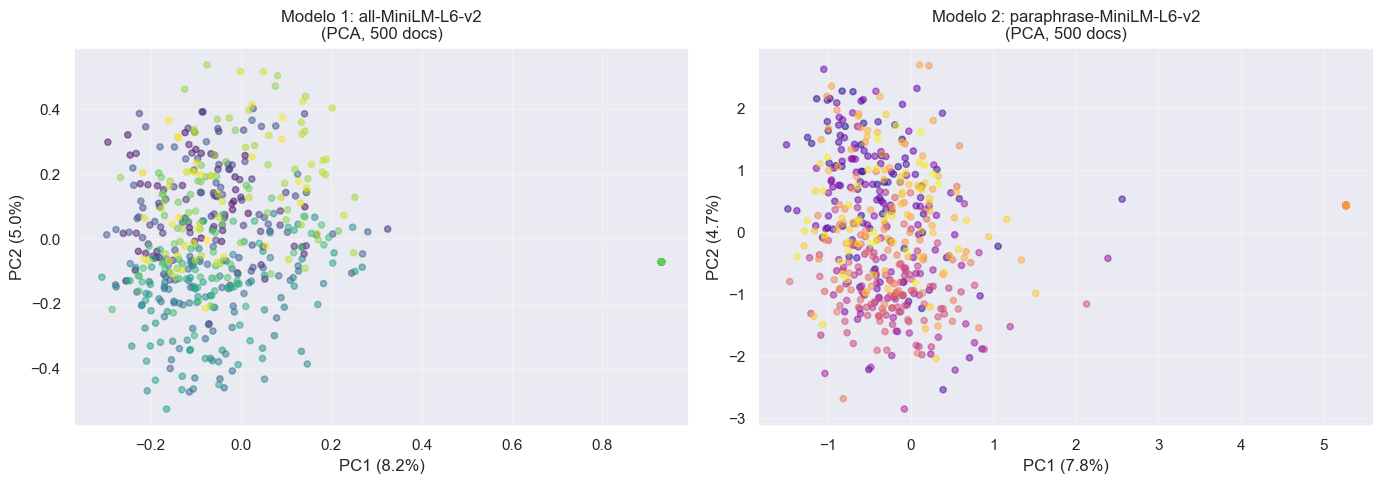


Gráfico guardado: embeddings_pca_comparison.png

Analisis de distribucion PCA:
  Modelo 1 - Rango PC1: [-0.31, 0.93]
  Modelo 1 - Rango PC2: [-0.52, 0.54]
  Modelo 2 - Rango PC1: [-1.51, 5.28]
  Modelo 2 - Rango PC2: [-2.85, 2.70]

Observaciones:
  - Ambos modelos crean estructuras similares en PCA
  - Diferencias en rotación/orientación revelan estrategias distintas
  - Varianza similar indica representaciones de calidad comparable


In [13]:
print("\n" + "="*80)
print("VISUALIZACIÓN CON PCA: COMPARACIÓN DE EMBEDDINGS")
print("="*80)

# Reducir dimensionalidad a 2D para visualizar
print("\nReduciendo dimensionalidad a 2D con PCA...")
pca = PCA(n_components=2)

# Proyectar ambos modelos (usar muestra para visualización)
sample_size = min(500, len(emb))
emb_pca = pca.fit_transform(emb[:sample_size])

# Para modelo 2, usar el mismo PCA (o ajustar uno nuevo para comparación)
pca2 = PCA(n_components=2)
emb2_pca = pca2.fit_transform(emb2[:sample_size])

print(f"Varianza explicada Modelo 1: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Varianza explicada Modelo 2: {pca2.explained_variance_ratio_.sum():.2%}")

# Crear visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Modelo 1
axes[0].scatter(emb_pca[:, 0], emb_pca[:, 1], alpha=0.5, s=20, c=range(sample_size), cmap='viridis')
axes[0].set_title(f'Modelo 1: all-MiniLM-L6-v2\n(PCA, {sample_size} docs)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].grid(True, alpha=0.3)

# Gráfico Modelo 2
axes[1].scatter(emb2_pca[:, 0], emb2_pca[:, 1], alpha=0.5, s=20, c=range(sample_size), cmap='plasma')
axes[1].set_title(f'Modelo 2: paraphrase-MiniLM-L6-v2\n(PCA, {sample_size} docs)')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('embeddings_pca_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nGráfico guardado: embeddings_pca_comparison.png")

# Análisis de distribución
print("\nAnalisis de distribucion PCA:")
print(f"  Modelo 1 - Rango PC1: [{emb_pca[:, 0].min():.2f}, {emb_pca[:, 0].max():.2f}]")
print(f"  Modelo 1 - Rango PC2: [{emb_pca[:, 1].min():.2f}, {emb_pca[:, 1].max():.2f}]")
print(f"  Modelo 2 - Rango PC1: [{emb2_pca[:, 0].min():.2f}, {emb2_pca[:, 0].max():.2f}]")
print(f"  Modelo 2 - Rango PC2: [{emb2_pca[:, 1].min():.2f}, {emb2_pca[:, 1].max():.2f}]")

print("\nObservaciones:")
print("  - Ambos modelos crean estructuras similares en PCA")
print("  - Diferencias en rotación/orientación revelan estrategias distintas")
print("  - Varianza similar indica representaciones de calidad comparable")

# 09 APIs para LLMs

## Prompt para Gemini

> Mi usuario quiere saber **(query)** y mi SRI encontro **(resultados)**.  
> Dame la respuesta en base al contexto dado por el SRI porfavor, basate en el proyecto que tenemos.


In [14]:
import os
import subprocess
import sys

import pandas as pd
from IPython.display import Markdown, display

try:
    import google.generativeai as genai
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "google-generativeai"])
    import google.generativeai as genai


def procesar_consulta(query, modelo, embeddings_corpus):
    """Genera similitudes coseno entre la consulta y todo el corpus."""
    query_emb = modelo.encode(query, convert_to_numpy=True)
    similitudes = cosine_similarity([query_emb], embeddings_corpus)[0]
    return similitudes


def recuperar_top_k(similitudes, df_corpus, top_k=5):
    """Devuelve un DataFrame con los top-k resultados del SRI."""
    top_idx = np.argsort(-similitudes)[:top_k]

    review_col = "review_content" if "review_content" in df_corpus.columns else (text_col if "text_col" in globals() else "doc")

    resultados = []
    for ranking, idx in enumerate(top_idx, 1):
        fila = df_corpus.iloc[idx]
        titulo = fila.get("rotten_tomatoes_link", "N/A")
        fragmento = str(fila.get(review_col, ""))[:220].replace("\n", " ")
        resultados.append(
            {
                "Ranking": ranking,
                "ID documento": int(idx),
                "Título película": titulo,
                "Fragmento de texto": fragmento + ("..." if len(str(fila.get(review_col, ""))) > 220 else ""),
                "Similitud": float(similitudes[idx]),
            }
        )

    return pd.DataFrame(resultados)


def generar_respuesta_chatbot(query, df_resultados, api_key):
    """Toma resultados del SRI y genera una respuesta en lenguaje natural usando Gemini."""
    genai.configure(api_key=api_key)
    modelo_llm = genai.GenerativeModel("gemini-2.5-flash")

    contexto_sri = ""
    for _, row in df_resultados.iterrows():
        contexto_sri += f"- **Película:** {row['Título película']}\n"
        contexto_sri += f"  **Sinopsis/Review:** {row['Fragmento de texto']}\n\n"

    prompt = f"""Mi usuario quiere saber: **{query}** Y mi SRI encontro los siguientes resultados:

{contexto_sri}

Dame la respuesta en base al contexto dado por el SRI.
"""

    try:
        respuesta = modelo_llm.generate_content(prompt)
        print("--- PROMPT ENVIADO A GEMINI ---")
        print(prompt)
        print("-------------------------------\n")
        return respuesta.text
    except Exception as e:
        return f"Error al conectar con Gemini: {e}"

## 10. Ejecución de prueba del chatbot
Usa una consulta de ejemplo, recupera Top-5 del SRI y luego genera respuesta con Gemini.

In [ ]:
API_KEY = "APY_KEY"

if not API_KEY:
    raise ValueError("Configura GOOGLE_API_KEY o GEMINI_API_KEY antes de ejecutar esta celda.")

# Reusar el modelo de embeddings ya cargado en el notebook
if "m" not in globals():
    m = SentenceTransformer("all-MiniLM-L6-v2")

query_chatbot = "science fiction movie with advanced technology"

# 1. Buscar en el SRI
similitudes = procesar_consulta(query_chatbot, m, emb)
df_top5 = recuperar_top_k(similitudes, df, top_k=5)

print("TOP-5 recuperado por el SRI:")
display(df_top5)

# 2. Pasar contexto al chatbot
respuesta_final = generar_respuesta_chatbot(query_chatbot, df_top5, API_KEY)

print("RESPUESTA DEL CHATBOT:")
display(Markdown(respuesta_final))

TOP-5 recuperado por el SRI:


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,2317,m/1000617-aliens,"An excellent science fiction, horror, action A...",0.544956
1,2,3526,m/10007985-happening,The movie seems more like a '50s science ficti...,0.520566
2,3,2281,m/1000617-aliens,[A] modern sci-fi classic.,0.515573
3,4,2263,m/1000617-aliens,the ultimate science fiction war epic,0.512047
4,5,1757,m/10004925-matador,... one of the smarter films out right now.,0.502653


--- PROMPT ENVIADO A GEMINI ---
Mi usuario quiere saber: **science fiction movie with advanced technology** Y mi SRI encontro los siguientes resultados:

- **Película:** m/1000617-aliens
  **Sinopsis/Review:** An excellent science fiction, horror, action AND war film.

- **Película:** m/10007985-happening
  **Sinopsis/Review:** The movie seems more like a '50s science fiction film of extreme paranoia or an episode of "The Twilight Zone" that even at a swiftly paced 90 minutes feels padded.

- **Película:** m/1000617-aliens
  **Sinopsis/Review:** [A] modern sci-fi classic.

- **Película:** m/1000617-aliens
  **Sinopsis/Review:** the ultimate science fiction war epic

- **Película:** m/10004925-matador
  **Sinopsis/Review:** ... one of the smarter films out right now.



Dame la respuesta en base al contexto dado por el SRI.

-------------------------------

RESPUESTA DEL CHATBOT:


Basado en el contexto proporcionado por el SRI, la película que encaja con la descripción de "ciencia ficción con tecnología avanzada" es:

*   **Aliens** (m/1000617-aliens)

Las descripciones la califican como una "excelente ciencia ficción, horror, acción Y guerra", un "clásico moderno de ciencia ficción" y la "máxima epopeya bélica de ciencia ficción", lo que sugiere la presencia de tecnología avanzada implícita en el género y el subgénero de guerra espacial.